## Análisis de Piloto

En este notebook se realiza lo siguiente:
+ Análisis de la campaña piloto de entrega de tarjetas físicas de débito.
+ Modelo de ML para decidir a quíen se debería priorizar para la siguiente ola de entrega.

### Campaña

In [1]:
import sys
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import causalml.metrics as causalml_metrics
from scipy.stats import wilcoxon, mannwhitneyu
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from causalml.inference.meta import BaseTClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(REPO_ROOT)

from src.sagemaker.train_uplift import (
    TRATAMIENTO, CONTROL, UMBRAL_ALERTA_SMD, FEATURES_NUMERICAS_COMPLETAS, FEATURES_CATEGORICAS_COMPLETAS,
    construir_panel, chequear_balance_covariables, construir_preprocesador,
)
from src.sagemaker.score_uplift import UMBRAL_SEGMENTO, clasificar_segmento

cliente_360 = pd.read_parquet(f"{REPO_ROOT}/data/curated/cliente_360")
transacciones = pd.read_parquet(f"{REPO_ROOT}/data/processed/transacciones")
transacciones["fecha"] = pd.to_datetime(transacciones["fecha"])

print(f"cliente_360: {cliente_360.shape}")
print(f"transacciones (processed): {transacciones.shape}")

cliente_360: (12000, 72)
transacciones (processed): (189552, 7)


**Adopción, activación, y el efecto antes/después de activar la tarjeta física.**

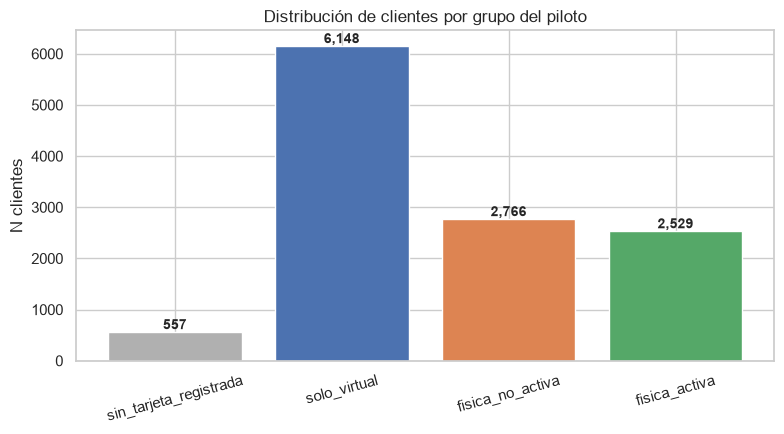

Clientes totales: 12,000
Recibieron tarjeta física: 5,295 (44.1% de la base)
Activaron la tarjeta física: 2,529 (47.8% de quienes la recibieron)


In [2]:
orden_grupos = ["sin_tarjeta_registrada", "solo_virtual", "fisica_no_activa", "fisica_activa"]
colores_grupos = {"sin_tarjeta_registrada": "#B0B0B0", "solo_virtual": "#4C72B0",
                   "fisica_no_activa": "#DD8452", "fisica_activa": "#55A868"}

conteo_grupos = cliente_360["grupo_piloto"].value_counts().reindex(orden_grupos)

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(conteo_grupos.index, conteo_grupos.values,
                 color=[colores_grupos[g] for g in conteo_grupos.index])
for barra, valor in zip(barras, conteo_grupos.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 60, f"{valor:,}",
            ha="center", fontsize=10, fontweight="bold")
ax.set_title("Distribución de clientes por grupo del piloto")
ax.set_ylabel("N clientes")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

n_total = len(cliente_360)
n_recibio_fisica = (cliente_360["tiene_tarjeta_fisica"]).sum()
n_activo = (cliente_360["fisica_activada"]).sum()
print(f"Clientes totales: {n_total:,}")
print(f"Recibieron tarjeta física: {n_recibio_fisica:,} ({n_recibio_fisica/n_total:.1%} de la base)")
print(f"Activaron la tarjeta física: {n_activo:,} ({n_activo/n_recibio_fisica:.1%} de quienes la recibieron)")

Efecto antes/después de activar solo dentro del grupo `fisica_activa`. 

Esta comparación es dentro del mismo cliente, pre vs. post su propia fecha de activación, muestra que el uso subió, pero **no** aísla si hubiera subido igual sin la tarjeta.

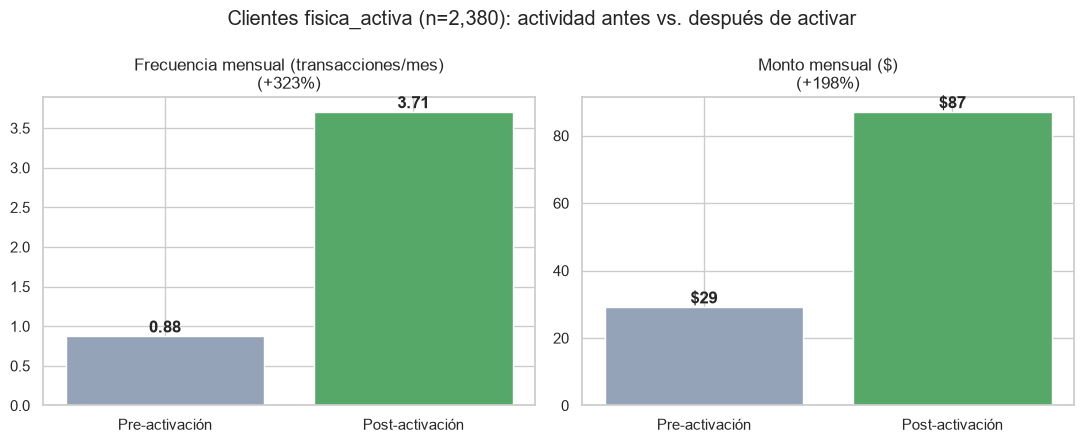

Wilcoxon pareado, frecuencia mensual post > pre: estadístico=23203, p-valor=0.00e+00
Wilcoxon pareado, monto mensual post > pre:      estadístico=140698, p-valor=0.00e+00


In [3]:
activos = cliente_360[cliente_360["grupo_piloto"] == "fisica_activa"].dropna(
    subset=["frecuencia_mensual_pre", "frecuencia_mensual_post", "monto_mensual_pre", "monto_mensual_post"]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (pre_c, post_c, titulo, fmt) in zip(axes, [
    ("frecuencia_mensual_pre", "frecuencia_mensual_post", "Frecuencia mensual (transacciones/mes)", "{:.2f}"),
    ("monto_mensual_pre", "monto_mensual_post", "Monto mensual ($)", "${:.0f}"),
]):
    medias = [activos[pre_c].mean(), activos[post_c].mean()]
    barras = ax.bar(["Pre-activación", "Post-activación"], medias, color=["#94A3B8", "#55A868"])
    for barra, v in zip(barras, medias):
        ax.text(barra.get_x() + barra.get_width() / 2, v, fmt.format(v), ha="center", va="bottom", fontweight="bold")
    pct = (medias[1] / medias[0] - 1) * 100
    ax.set_title(f"{titulo}\n(+{pct:.0f}%)")
plt.suptitle(f"Clientes fisica_activa (n={len(activos):,}): actividad antes vs. después de activar")
plt.tight_layout()
plt.show()

# prueba pareada: mismo cliente, dos mediciones -> Wilcoxon (no asume normalidad)
stat_freq, p_freq = wilcoxon(activos["frecuencia_mensual_post"], activos["frecuencia_mensual_pre"])
stat_monto, p_monto = wilcoxon(activos["monto_mensual_post"], activos["monto_mensual_pre"])
print(f"Wilcoxon pareado, frecuencia mensual post > pre: estadístico={stat_freq:.0f}, p-valor={p_freq:.2e}")
print(f"Wilcoxon pareado, monto mensual post > pre:      estadístico={stat_monto:.0f}, p-valor={p_monto:.2e}")

Señal pre-existente: `fisica_activa` ya se comportaba distinto ANTES de tener la tarjeta

Antes de recibir la tarjeta, quienes luego la activan ya muestran más actividad que quienes se quedan solo con virtual.

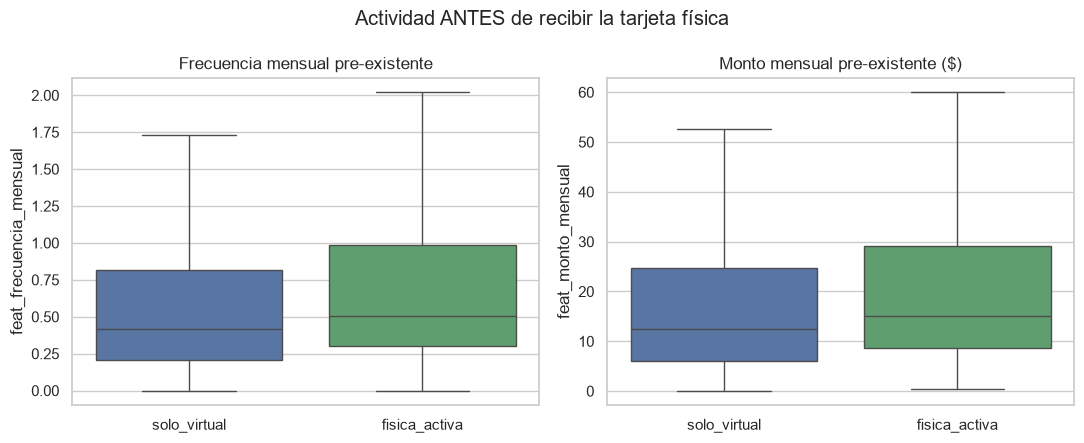

frecuencia mensual: fisica_activa media=1.11 vs solo_virtual media=0.93 | Mann-Whitney U (fisica_activa > solo_virtual) p-valor=1.02e-19
monto mensual: fisica_activa media=36.33 vs solo_virtual media=29.20 | Mann-Whitney U (fisica_activa > solo_virtual) p-valor=1.70e-18


In [4]:
comparar = cliente_360[cliente_360["grupo_piloto"].isin(["fisica_activa", "solo_virtual"])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, titulo in zip(
    axes,
    ["feat_frecuencia_mensual", "feat_monto_mensual"],
    ["Frecuencia mensual pre-existente", "Monto mensual pre-existente ($)"],
):
    sns.boxplot(data=comparar, x="grupo_piloto", y=col, order=["solo_virtual", "fisica_activa"],
                palette=[colores_grupos["solo_virtual"], colores_grupos["fisica_activa"]], ax=ax, showfliers=False)
    ax.set_title(titulo)
    ax.set_xlabel("")
plt.suptitle("Actividad ANTES de recibir la tarjeta física")
plt.tight_layout()
plt.show()

for col, nombre in [("feat_frecuencia_mensual", "frecuencia mensual"), ("feat_monto_mensual", "monto mensual")]:
    a = comparar.loc[comparar["grupo_piloto"] == "fisica_activa", col].dropna()
    b = comparar.loc[comparar["grupo_piloto"] == "solo_virtual", col].dropna()
    u, p = mannwhitneyu(a, b, alternative="greater")
    print(f"{nombre}: fisica_activa media={a.mean():.2f} vs solo_virtual media={b.mean():.2f} "
          f"| Mann-Whitney U (fisica_activa > solo_virtual) p-valor={p:.2e}")

De acuerdo con los gráficos anteriores se podría decir que en efecto, entregar una tarjeta de débito física aumenta el monto y la frecuencia, es importante verificar que este comportamiento sea causa de la campaña piloto; en este caso se realiz un análisis DiD para verificar esto bajo el supuesto de tener tendencias paralelas, es decir que sin el piloto, el grupo de tratamiento y control habrían evolucionado igual.

Para esto se considera que:


+ **Fecha de corte:** la emisión de tarjetas físicas se concentra casi toda el 2026-05-01, fecha de lanzamiento de piloto.
+ **Grupo Tratado:** `fisica_activa` (recibió y activó). 
+ **Control:** `solo_virtual` (nunca recibió). 
+ Se excluye `fisica_no_activa` de este análisis (recibió pero no activó, no es ni tratado "puro" ni control) y `sin_tarjeta_registrada` (vacío de datos).


In [5]:
CORTE = pd.Timestamp("2026-05-01")
PRE_INICIO = pd.Timestamp("2026-03-01")
POST_FIN = pd.Timestamp("2026-07-01")
DIAS_POR_MES = 30.44

panel_clientes = cliente_360[cliente_360["grupo_piloto"].isin(["fisica_activa", "solo_virtual"])].copy()
panel_clientes["fecha_registro"] = pd.to_datetime(panel_clientes["fecha_registro"])

# exige historial en ambas ventanas para una comparación justa
panel_clientes = panel_clientes[panel_clientes["fecha_registro"] < PRE_INICIO]
panel_clientes["tratado"] = (panel_clientes["grupo_piloto"] == "fisica_activa").astype(int)

tx_did = transacciones[transacciones["cliente_id"].isin(panel_clientes["cliente_id"])]
tx_did = tx_did[(tx_did["fecha"] >= PRE_INICIO) & (tx_did["fecha"] < POST_FIN)]
tx_did = tx_did.copy()
tx_did["periodo"] = np.where(tx_did["fecha"] < CORTE, "pre", "post")

conteo = tx_did.groupby(["cliente_id", "periodo"]).size().unstack(fill_value=0)
conteo = conteo.reindex(columns=["pre", "post"], fill_value=0)
conteo["frecuencia_pre"] = conteo["pre"] / ((CORTE - PRE_INICIO).days / DIAS_POR_MES)
conteo["frecuencia_post"] = conteo["post"] / ((POST_FIN - CORTE).days / DIAS_POR_MES)

panel = panel_clientes.set_index("cliente_id")[["tratado"]].join(conteo[["frecuencia_pre", "frecuencia_post"]], how="left")
panel[["frecuencia_pre", "frecuencia_post"]] = panel[["frecuencia_pre", "frecuencia_post"]].fillna(0)

print(f"Panel DiD: {len(panel):,} clientes (tratado={panel['tratado'].sum():,}, control={(1-panel['tratado']).sum():,})")

Panel DiD: 8,079 clientes (tratado=2,331, control=5,748)


                         frecuencia_pre  frecuencia_post
control (solo_virtual)            0.645            0.662
tratado (fisica_activa)           0.738            4.338


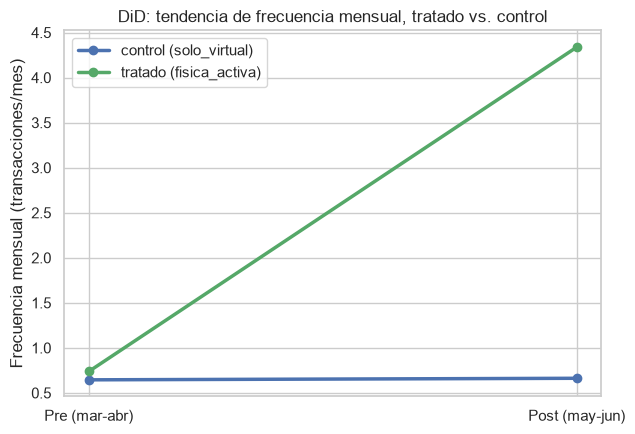

In [6]:
resumen_did = panel.groupby("tratado")[["frecuencia_pre", "frecuencia_post"]].mean()
resumen_did.index = ["control (solo_virtual)", "tratado (fisica_activa)"]
print(resumen_did.round(3))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for (grupo, fila), color in zip(resumen_did.iterrows(), ["#4C72B0", "#55A868"]):
    ax.plot(["Pre (mar-abr)", "Post (may-jun)"], [fila["frecuencia_pre"], fila["frecuencia_post"]],
            marker="o", linewidth=2.5, label=grupo, color=color)
ax.set_ylabel("Frecuencia mensual (transacciones/mes)")
ax.set_title("DiD: tendencia de frecuencia mensual, tratado vs. control")
ax.legend()
plt.tight_layout()
plt.show()

El grupo tratado sube `3.583` transacciones/mes MÁS que lo que subió o bajó el control en la misma ventana, este es el efecto atribuible a la tarjeta física bajo el supuesto de tendencias paralelas, no una comparación cruda antes/después

In [7]:
panel_largo = panel.reset_index().melt(
    id_vars=["cliente_id", "tratado"], value_vars=["frecuencia_pre", "frecuencia_post"],
    var_name="periodo", value_name="frecuencia"
)
panel_largo["post"] = (panel_largo["periodo"] == "frecuencia_post").astype(int)

modelo_did = smf.ols("frecuencia ~ tratado * post", data=panel_largo).fit(cov_type="HC1")
print(modelo_did.summary().tables[1])

coef_did = modelo_did.params["tratado:post"]
p_did = modelo_did.pvalues["tratado:post"]
print(f"\nEstimador DiD (tratado:post) = {coef_did:+.3f} transacciones/mes, p-valor = {p_did:.2e}")

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.6450      0.012     51.618      0.000       0.621       0.670
tratado          0.0927      0.024      3.856      0.000       0.046       0.140
post             0.0172      0.018      0.948      0.343      -0.018       0.053
tratado:post     3.5834      0.049     72.673      0.000       3.487       3.680

Estimador DiD (tratado:post) = +3.583 transacciones/mes, p-valor = 0.00e+00


### Modelo Uplift

En esta parte se desarrolla el modelo uplift, se escoge esta metodología puesto que dado el contexto de negocio de que se tiene un presupuesto limitado para la siguiente ola, se quiere priorizar y econtrar a las personas que dado que les voy a dar una tarjeta física, cambie su comportamiento de consumo, es decir, se necesita identificar a clientes que necesiten un estímulo para que empiecen a consumir más y no se quiere gastar entregando tarjetas a quienes nunca cambiaran su comportamiento o a personas que de igual forma con o sin tarjeta seguiran aumentando su consumo e inclusive identificar a los clientes que por la insistencia de la contactabilidad deje de usarme.

Es por esto que se construye un modelo T-Learner y a partir del ICE identificar 4 grupos.

+ Persuadibles: Aumentarán el consumo si se les da una tarjeta física.
+ Seguros: Aumentarán el consumo con o sin tarjeta física.
+ Perdidos: No aumentarán su consumo con o sin tarjeta física.
+ Perros dormidos: Disminuirán su consumo si se les da una tarjeta física

Panel: 7,361 clientes (tratado=2,125, control=5,236)


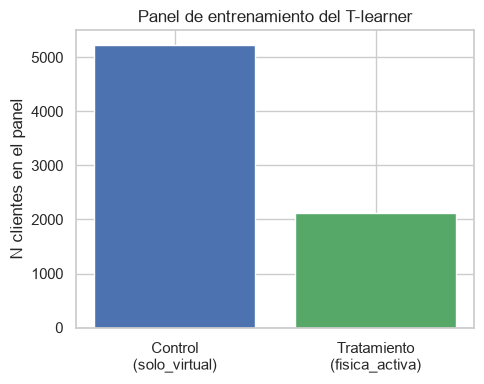

In [8]:
panel = construir_panel(cliente_360, transacciones)
cols = FEATURES_NUMERICAS_COMPLETAS + FEATURES_CATEGORICAS_COMPLETAS
panel = panel.dropna(subset=FEATURES_NUMERICAS_COMPLETAS)

n_tratado = int((panel["tratado"] == TRATAMIENTO).sum())
n_control = int((panel["tratado"] == CONTROL).sum())
print(f"Panel: {len(panel):,} clientes (tratado={n_tratado:,}, control={n_control:,})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Control\n(solo_virtual)", "Tratamiento\n(fisica_activa)"], [n_control, n_tratado],
       color=["#4C72B0", "#55A868"])
ax.set_ylabel("N clientes en el panel")
ax.set_title("Panel de entrenamiento del T-learner")
plt.tight_layout()
plt.show()

Dada la diferencia entre el control y tratamiento, podría ser que no existan muestras o sujetos de similares características, por lo que se podría realizar un PSM para obtener el grupo de control y tratamiento con características similares. Sin embargo los valores de SMD son cercanos a cero, por lo que estamos trabajando con muestras de similares características.

Balance de covariables OK (todas las |SMD| <= 0.25) -- consistente con asignación aleatoria, no se aplica Propensity Score Matching.
                       feature  media_tratado  media_control    smd
       feat_frecuencia_mensual          0.749          0.606  0.187
            feat_monto_mensual         25.868         19.594  0.068
       feat_pct_compra_tarjeta          0.001          0.002 -0.051
    feat_n_categorias_comercio          0.015          0.032 -0.058
feat_n_interacciones_marketing          3.062          3.149 -0.054
 feat_tasa_respuesta_marketing          0.321          0.310  0.033
                     feat_edad         43.974         46.259 -0.142
          feat_antiguedad_dias       1086.838       1096.308 -0.017


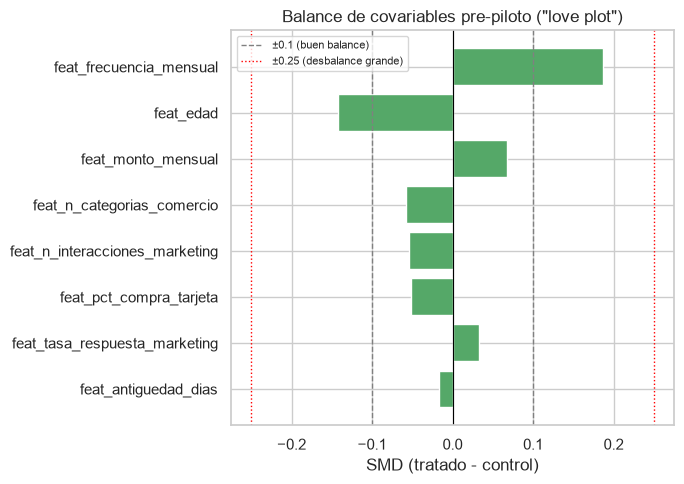

In [9]:
tabla_smd = chequear_balance_covariables(panel, FEATURES_NUMERICAS_COMPLETAS)
print(tabla_smd.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
orden = tabla_smd.sort_values("smd", key=abs)
colores = ["#C44E52" if abs(v) > UMBRAL_ALERTA_SMD else "#55A868" for v in orden["smd"]]
ax.barh(orden["feature"], orden["smd"], color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.1, color="gray", linestyle="--", linewidth=1, label="±0.1 (buen balance)")
ax.axvline(-0.1, color="gray", linestyle="--", linewidth=1)
ax.axvline(UMBRAL_ALERTA_SMD, color="red", linestyle=":", linewidth=1, label=f"±{UMBRAL_ALERTA_SMD} (desbalance grande)")
ax.axvline(-UMBRAL_ALERTA_SMD, color="red", linestyle=":", linewidth=1)
ax.set_xlabel("SMD (tratado - control)")
ax.set_title("Balance de covariables pre-piloto (\"love plot\")")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Definimos `aumento_uso` = 1 si `frecuencia_post > frecuencia_pre` 

Target: ¿subió la frecuencia de transacciones de la ventana pre-corte a la post-corte?

Al parecer las personas que recibieron su tarjeta física si aumentaron su consumo y concuerda con el resultado de DiD.

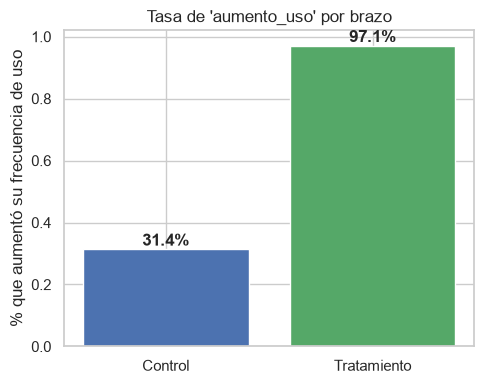

Diferencia cruda de tasas (no ajustada): +65.7%


In [10]:
tasas = panel.groupby("tratado")["aumento_uso"].mean()
fig, ax = plt.subplots(figsize=(5, 4))
barras = ax.bar(["Control", "Tratamiento"], [tasas[CONTROL], tasas[TRATAMIENTO]], color=["#4C72B0", "#55A868"])
for b, v in zip(barras, [tasas[CONTROL], tasas[TRATAMIENTO]]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1%}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("% que aumentó su frecuencia de uso")
ax.set_title("Tasa de 'aumento_uso' por brazo")
plt.tight_layout()
plt.show()
print(f"Diferencia cruda de tasas (no ajustada): {tasas[TRATAMIENTO]-tasas[CONTROL]:+.1%}")

Entrenamiento `T-Learner`.

In [11]:
train_df, test_df = train_test_split(
    panel, test_size=0.25, random_state=42, stratify=panel[["tratado", "aumento_uso"]]
)

preprocesador = construir_preprocesador()
X_train = preprocesador.fit_transform(train_df[cols])
X_test = preprocesador.transform(test_df[cols])
treatment_train = train_df["tratado"].to_numpy()
treatment_test = test_df["tratado"].to_numpy()
y_train = train_df["aumento_uso"].to_numpy()
y_test = test_df["aumento_uso"].to_numpy()

learner = BaseTClassifier(
    learner=RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1),
    control_name=CONTROL,
)
learner.fit(X=X_train, treatment=treatment_train, y=y_train)
print("T-learner entrenado (modelo de control + modelo de tratamiento)")

T-learner entrenado (modelo de control + modelo de tratamiento)


AUC modelo control:      0.612
AUC modelo tratamiento:  0.702

ATE (efecto promedio del tratamiento) = +41.4%  (IC 95%: [+39.0%, +43.7%])


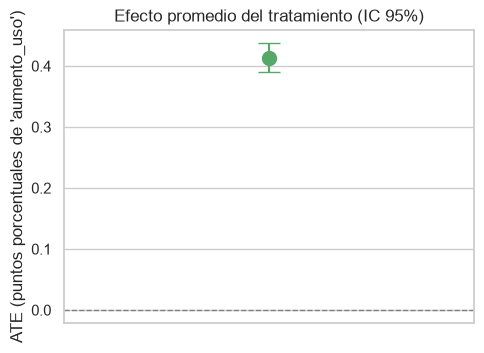

In [12]:
mask_c, mask_t = treatment_test == CONTROL, treatment_test == TRATAMIENTO
auc_control = roc_auc_score(y_test[mask_c], learner.model_c.predict_proba(X_test[mask_c])[:, 1])
auc_tratamiento = roc_auc_score(y_test[mask_t], learner.models_t[TRATAMIENTO].predict_proba(X_test[mask_t])[:, 1])
print(f"AUC modelo control:      {auc_control:.3f}")
print(f"AUC modelo tratamiento:  {auc_tratamiento:.3f}")

ate, ate_lb, ate_ub = learner.estimate_ate(X=X_test, treatment=treatment_test, y=y_test)
ate, ate_lb, ate_ub = float(np.ravel(ate)[0]), float(np.ravel(ate_lb)[0]), float(np.ravel(ate_ub)[0])
print(f"\nATE (efecto promedio del tratamiento) = {ate:+.1%}  (IC 95%: [{ate_lb:+.1%}, {ate_ub:+.1%}])")


fig, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar([0], [ate], yerr=[[ate - ate_lb], [ate_ub - ate]], fmt="o", markersize=10, capsize=8, color="#55A868")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlim(-1, 1)
ax.set_xticks([])
ax.set_ylabel("ATE (puntos porcentuales de 'aumento_uso')")
ax.set_title("Efecto promedio del tratamiento (IC 95%)")
plt.tight_layout()
plt.show()

Distribución del uplift individual (`tau`) y curva Qini

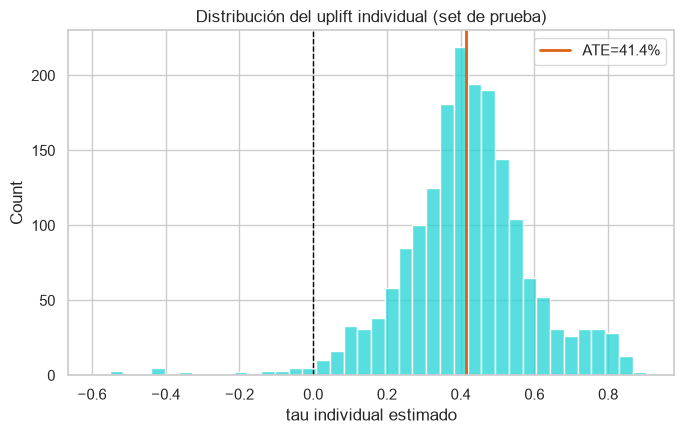

In [13]:
tau_test = learner.predict(X=X_test).ravel()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(tau_test, bins=40, color="#20D4D4", ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(ate, color="#DD6414", linestyle="-", linewidth=2, label=f"ATE={ate:.1%}")
ax.set_xlabel("tau individual estimado")
ax.set_title("Distribución del uplift individual (set de prueba)")
ax.legend()
plt.tight_layout()
plt.show()

Qini score: 0.1475 (positivo = el ranking por tau prioriza mejor que al azar)


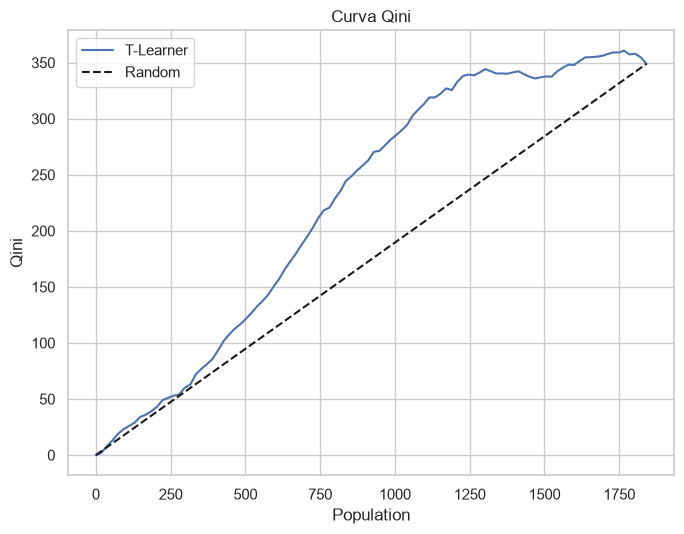

In [14]:
df_qini = pd.DataFrame({"y": y_test, "w": treatment_test, "T-Learner": tau_test})
qini_val = causalml_metrics.qini_score(df_qini, outcome_col="y", treatment_col="w")
print(f"Qini score: {qini_val['T-Learner']:.4f} (positivo = el ranking por tau prioriza mejor que al azar)")

fig, ax = plt.subplots(figsize=(7, 5.5))
causalml_metrics.plot_qini(df_qini, outcome_col="y", treatment_col="w", ax=ax)
ax.set_title("Curva Qini")
plt.tight_layout()
plt.show()

Interpretación del modelo

In [15]:
nombres_encoded = list(preprocesador.get_feature_names_out())

importancia = learner.get_importance(X=X_test, tau=tau_test, features=nombres_encoded, method="auto")
print(importancia)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

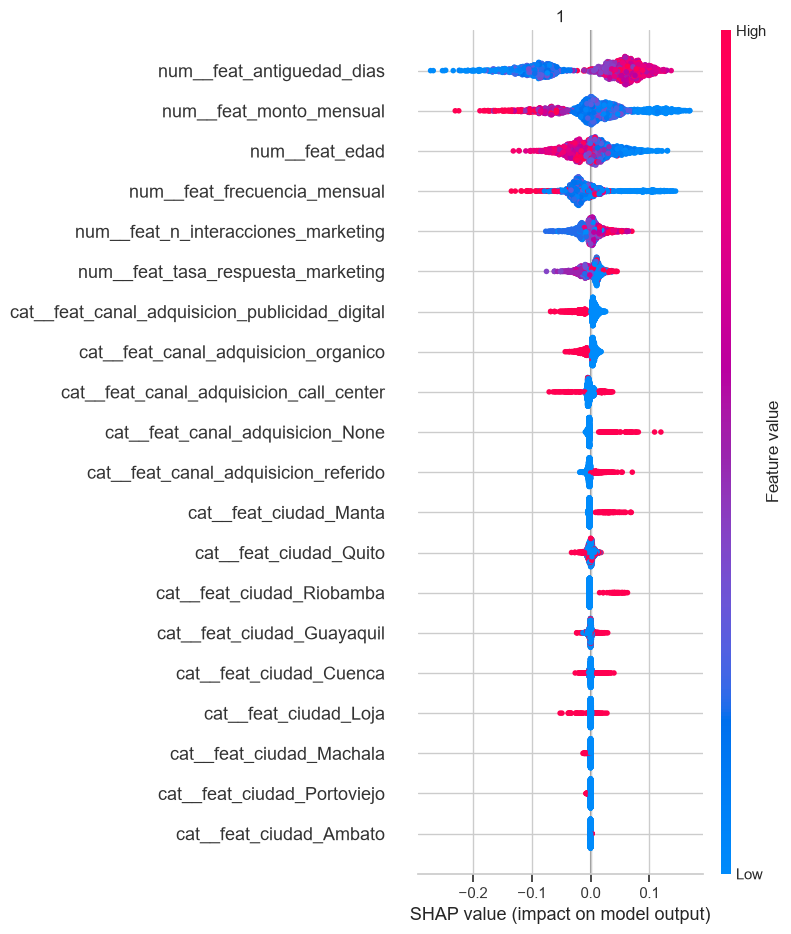

In [16]:
shap_dict = learner.get_shap_values(X=X_test, tau=tau_test, features=nombres_encoded)
learner.plot_shap_values(X=X_test, tau=tau_test, features=nombres_encoded, shap_dict=shap_dict)

Con respecto a las variables que explican el comportamiento, se tiene que a mayor antiguedad, mayor es la probabilidad de que cambie su comportamiento de consumo cuando tenga su tajeta física, podrían ser clientes que son fieles y siempre están probando los productos. Con respecto al monto, mientras más bajo es, mayor probabilidad de que se active, es decir que con una tarjeta, podrán consumir más.

Con el modelo entrenado, ahora lo aplicaremos a los clientes que no tienen tarjeta física y los clasificaremos en los 4 grupos mencionados anteriormente.

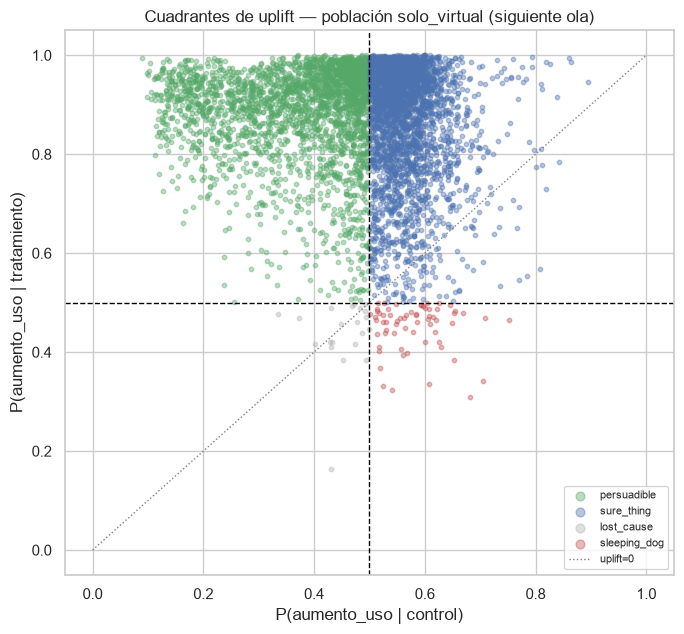

segmento_uplift
persuadible     2801
sure_thing      3261
lost_cause        21
sleeping_dog      65
Name: count, dtype: int64

segmento_uplift
persuadible     45.6%
sure_thing      53.0%
lost_cause       0.3%
sleeping_dog     1.1%
Name: count, dtype: object


In [17]:
poblacion_siguiente_ola = cliente_360[cliente_360["grupo_piloto"] == "solo_virtual"].copy()
X_scoring = preprocesador.transform(poblacion_siguiente_ola[cols])
p_control_scoring = learner.model_c.predict_proba(X_scoring)[:, 1]
p_tratamiento_scoring = learner.models_t[TRATAMIENTO].predict_proba(X_scoring)[:, 1]

poblacion_siguiente_ola["p_control"] = p_control_scoring
poblacion_siguiente_ola["p_tratamiento"] = p_tratamiento_scoring
poblacion_siguiente_ola["score_uplift"] = p_tratamiento_scoring - p_control_scoring
poblacion_siguiente_ola["segmento_uplift"] = [
    clasificar_segmento(pt, pc) for pt, pc in zip(p_tratamiento_scoring, p_control_scoring)
]

colores_segmento = {"persuadible": "#55A868", "sure_thing": "#4C72B0", "lost_cause": "#B0B0B0", "sleeping_dog": "#C44E52"}
orden_segmentos = ["persuadible", "sure_thing", "lost_cause", "sleeping_dog"]

fig, ax = plt.subplots(figsize=(7, 6.5))
for seg in orden_segmentos:
    sub = poblacion_siguiente_ola[poblacion_siguiente_ola["segmento_uplift"] == seg]
    ax.scatter(sub["p_control"], sub["p_tratamiento"], s=10, alpha=0.4, label=seg, color=colores_segmento[seg])
ax.axhline(UMBRAL_SEGMENTO, color="black", linestyle="--", linewidth=1)
ax.axvline(UMBRAL_SEGMENTO, color="black", linestyle="--", linewidth=1)
ax.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1, label="uplift=0")
ax.set_xlabel("P(aumento_uso | control)")
ax.set_ylabel("P(aumento_uso | tratamiento)")
ax.set_title("Cuadrantes de uplift — población solo_virtual (siguiente ola)")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

conteo_segmentos = poblacion_siguiente_ola["segmento_uplift"].value_counts().reindex(orden_segmentos)
print(conteo_segmentos)
print()
print((conteo_segmentos / len(poblacion_siguiente_ola)).apply(lambda x: f"{x:.1%}"))

### Recomendación


Tenemos que:

+ `persuadible`    : 2801 clientes (45.6%)
+ `seguros`     : 3261 clientes (53.0%)
+ `perdidos`     :    21 clientes (0.3%)
+ `perros dormidos`   :    65 clientes (1.1%)



1. **PRIORIZAR** "`persuadibles`" (2801 clientes, 45.6% de la siguiente ola candidata):
   
   Son los únicos donde la tarjeta física genera el cambio, el presupuesto limitado de tarjetas rinde más acá que en cualquier otro segmento. Esto es consistente con el ATE de +41.4%: la mayoría de ese efecto promedio viene de este grupo.

2. "`Seguros`" (3261 clientes, 53.0%): 
	
	Aumentarían su actividad con o sin tarjeta, si sobra presupuesto después de cubrir a los persuadibles, se les puede dar la tarjeta (no perjudica), pero no es donde más rinde.

3. "`Perdidos`" (21 clientes, 0.3%): 

	No vale la pena invertir tarjetas acá, ni con tarjeta cambiarían su comportamiento.

4. "`Perros dormidos`" (65 clientes, 1.1%): 

	Evitar darles la tarjeta, el modelo estima que podría reducir su actividad respecto a dejarlos solo con virtual (posible reacción negativa a más fricción/gasto en el canal físico).